In [1]:
import warnings
warnings.filterwarnings('ignore')
import os as os
import math
%run ccf_function.py
os.chdir('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/')
%matplotlib inline
from WildAlertpy import WRMDalert as alert
from WildAlertpy import read_data as read_data
from WildAlertpy import anomaly_2 as an
data_path = 'C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/wildalert exports/'
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.style as style
import numpy as np
style.use('fivethirtyeight')
plt.rcParams['font.family'] = 'Times New Roman'
sns.set_context("notebook", font_scale=1.30, rc={"lines.linewidth": 0.8})

## Brevetoxin data

In [2]:
Necropsy_brev_meta = pd.read_excel('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/Brevetoxin Data from Necropsy dwn 062625.xlsx', sheet_name='Nx Metadata')
#Necropsy_brev_meta.head()    

In [3]:
Necropsy_brev_meta['WH ID'].replace("2100029FWH", "2100029", inplace = True)
Necropsy_brev_meta['WH ID'].replace("2100027FWH", "2100027", inplace = True)
Necropsy_brev_meta['WH ID'].replace("2100028FWH", "2100028", inplace = True)
Necropsy_brev_meta['WH ID'].replace("220818-11", "220818", inplace = True)
Necropsy_brev_meta['WH ID'].replace("220922-01", "220922", inplace = True)

In [4]:
Necropsy_brev_results = pd.read_excel('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/Brevetoxin Data from Necropsy dwn 062625.xlsx', sheet_name='Sample Results')
#Necropsy_brev_results.head()

In [5]:
#print(Necropsy_brev_results['WH ID'].nunique())

In [6]:
#Necropsy_brev_results['WH ID'].unique()

In [7]:
#print(Necropsy_brev_meta['WH ID'].nunique())

In [8]:
#Necropsy_brev_meta['WH ID'].unique()

In [9]:
results_ids = Necropsy_brev_results['WH ID'].unique().tolist()
meta_ids = set(Necropsy_brev_meta['WH ID'].unique())  # use set for faster lookup

print(*[ID for ID in results_ids if ID not in meta_ids], sep='\n')

2100028
220818-11
220922-01
2100027
2100029


## New Code with interpretation

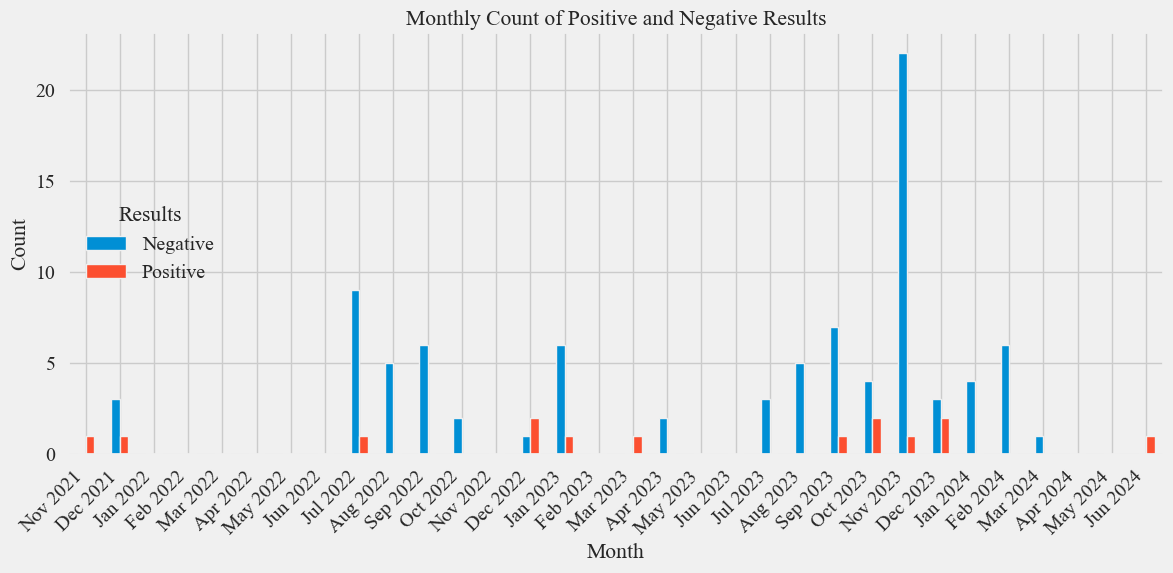

In [10]:
df = pd.merge(Necropsy_brev_results[['Necropsy Date', 'WH ID', 'Taxa Group',
                       'Species', 'Results (P/N)', 'Results Quant']], 
         Necropsy_brev_meta[['Mort Date', 'WH ID']], on='WH ID', how = 'left')
#df.head()
# Convert date columns to datetime
# Convert date columns to datetime
df['Mort Date'] = pd.to_datetime(df['Mort Date'], errors='coerce')
df['Necropsy Date'] = pd.to_datetime(df['Necropsy Date'], errors='coerce')
# Fill NaN values in 'Mort Date' with values from 'Necropsy Date'
df['Mort Date'] = df['Mort Date'].fillna(df['Necropsy Date'])
# Set 'Mort Date' as the datetime index
df.set_index('Mort Date', inplace=True)
# Group by month and count 'P' and 'N' results
monthly_counts = df.groupby([pd.Grouper(freq='M'), 'Results (P/N)']).size().unstack(fill_value=0)
# Ensure all months are represented, even if with zeros
monthly_counts = monthly_counts.asfreq('M', fill_value=0)
# Plotting the bar chart
ax = monthly_counts.plot(kind='bar', stacked=False, figsize=(12, 6))
# Customize x-axis to show only month and year
ax.set_xticklabels([x.strftime('%b %Y') for x in monthly_counts.index], rotation=45, ha='right')
plt.title('Monthly Count of Positive and Negative Results')
plt.xlabel('Month')
plt.ylabel('Count')
plt.grid(True, axis='y')
plt.legend(title='Results')
plt.tight_layout()
plt.show()

## SST and Florida Stranding

In [11]:
path  = 'C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/gulf_week_sst.csv'
sst = pd.read_csv(path)
sst.head()

,Unnamed: 0,by_week,observations,avg_algal_COUNT_,bird_latitude,bird_longitude,log_algal_count,cube_algal,nearest_latitude,nearest_longitude,sst
0,1,2015-12-27,1,0.000000,-27.352000,-82.41100,0.000000,0.000000,NaN,NaN,NaN
1,2,2016-01-03,734,0.000000,-27.352000,-82.41100,0.000000,0.000000,24.771044,-80.197097,289.48
2,3,2016-01-10,626,0.000000,-27.352000,-82.41100,0.000000,0.000000,NaN,NaN,NaN
3,4,2016-01-17,122,0.000000,-27.352000,-82.41100,0.000000,0.000000,NaN,NaN,NaN
4,5,2016-01-24,21,376045.363636,26.515996,-81.94522,12.837468,72.179424,NaN,NaN,NaN


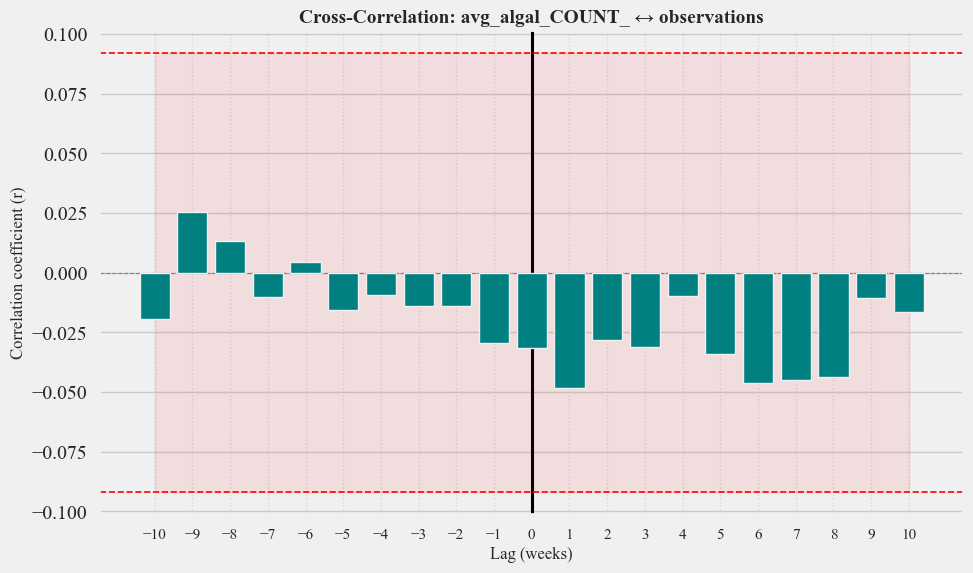


Cross-Correlation Table:

 Lag (weeks)  Correlation Coefficient (r)  Significant
         -10                    -0.019418        False
          -9                     0.025242        False
          -8                     0.013402        False
          -7                    -0.010303        False
          -6                     0.004535        False
          -5                    -0.015627        False
          -4                    -0.009565        False
          -3                    -0.014130        False
          -2                    -0.013966        False
          -1                    -0.029664        False
           0                    -0.031499        False
           1                    -0.048193        False
           2                    -0.028186        False
           3                    -0.031156        False
           4                    -0.009809        False
           5                    -0.034129        False
           6                    -0.046

(array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
          3,   4,   5,   6,   7,   8,   9,  10]),
 array([-0.01941781,  0.0252421 ,  0.01340203, -0.01030295,  0.00453497,
        -0.01562681, -0.00956461, -0.01413045, -0.01396608, -0.02966426,
        -0.03149916, -0.04819264, -0.0281856 , -0.0311563 , -0.00980897,
        -0.03412913, -0.04634112, -0.04479837, -0.0435137 , -0.01074774,
        -0.01646677]))

In [12]:
plot_cross_correlation(
    filepath='C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/gulf_week_sst.csv',
     obs_col='observations',
     algal_col='avg_algal_COUNT_',
     max_lag=10,
     direction='algal_vs_obs',
     interpret=True,
     save_path='C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/CCF_plot.png'
)

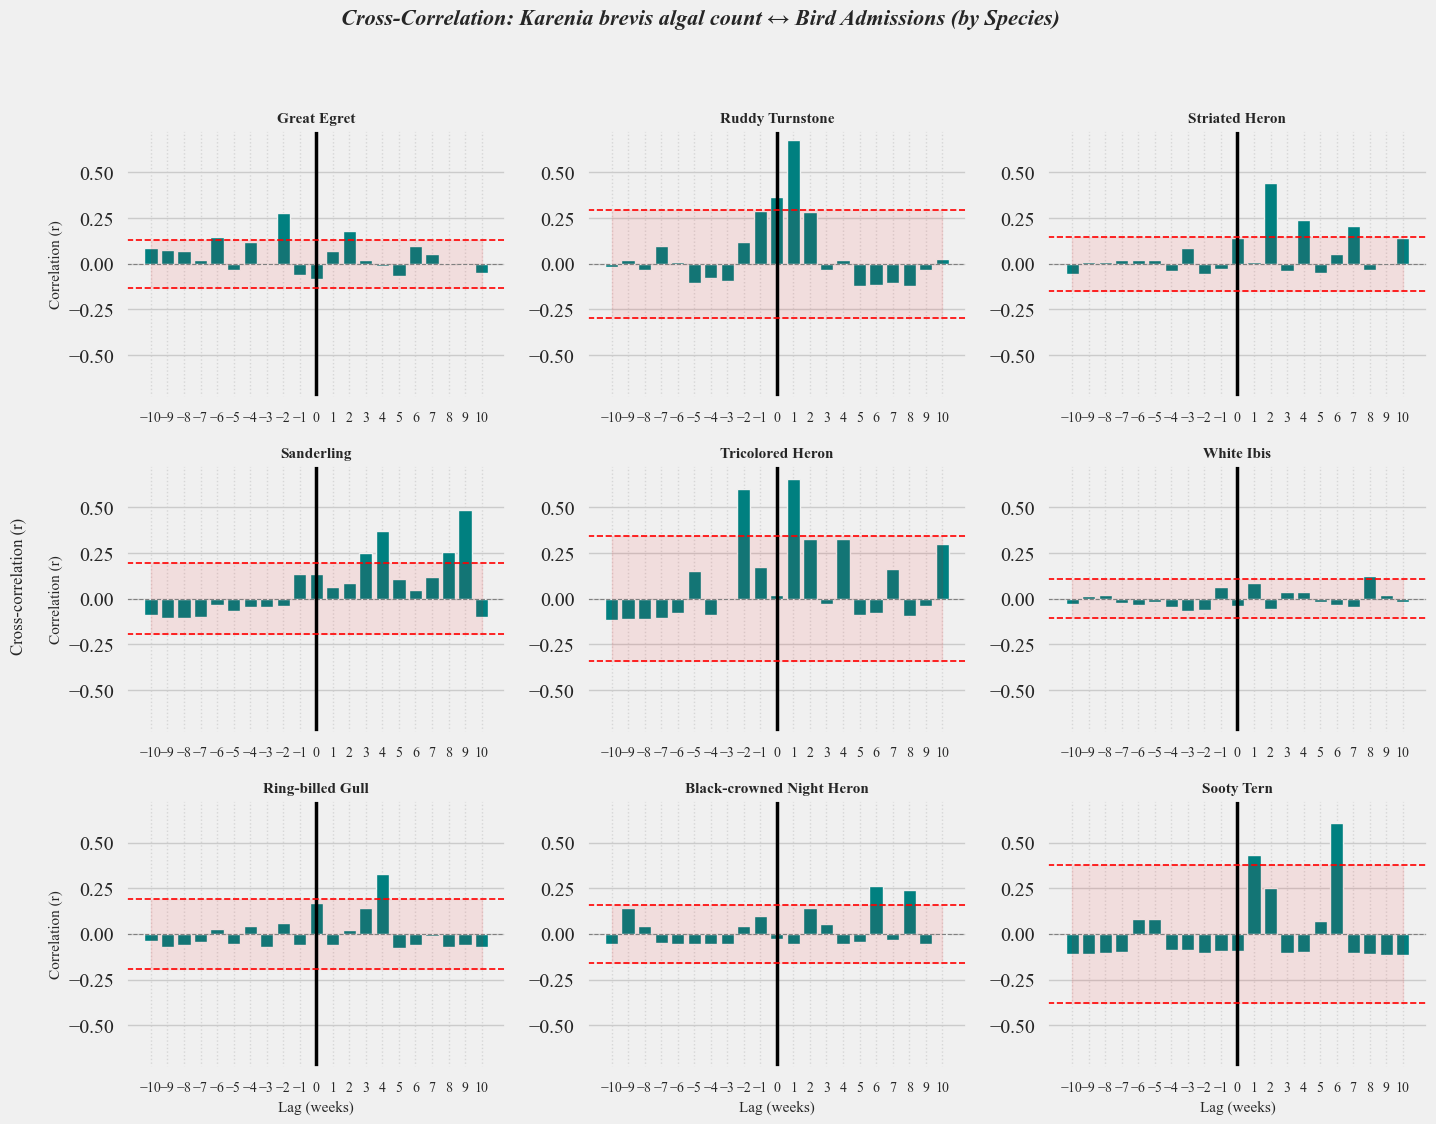

In [13]:
birds = {
    "Great Egret": "Ardea alba",
    "Ruddy Turnstone": "Arenaria interpres",
    "Striated Heron": "Butorides striata",
    "Sanderling": "Calidris alba",
    "Tricolored Heron": "Egretta tricolor",
    "White Ibis": "Eudocimus albus",
    "Ring-billed Gull": "Larus delawarensis",
    "Black-crowned Night Heron": "Nycticorax nycticorax",
    "Sooty Tern": "Onychoprion fuscatus"
}

plot_cross_correlation_grid(
    filepath='C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/gulf_week.csv',
    birds_dict=birds,
    obs_col='observations',
    algal_col='avg_algal_COUNT_',
    species_col='bird_speciesfull',
    max_lag=10,
    ci='bartlett',
    interpret=False,
    save_path='C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/CCF_9species_grid.png'
)

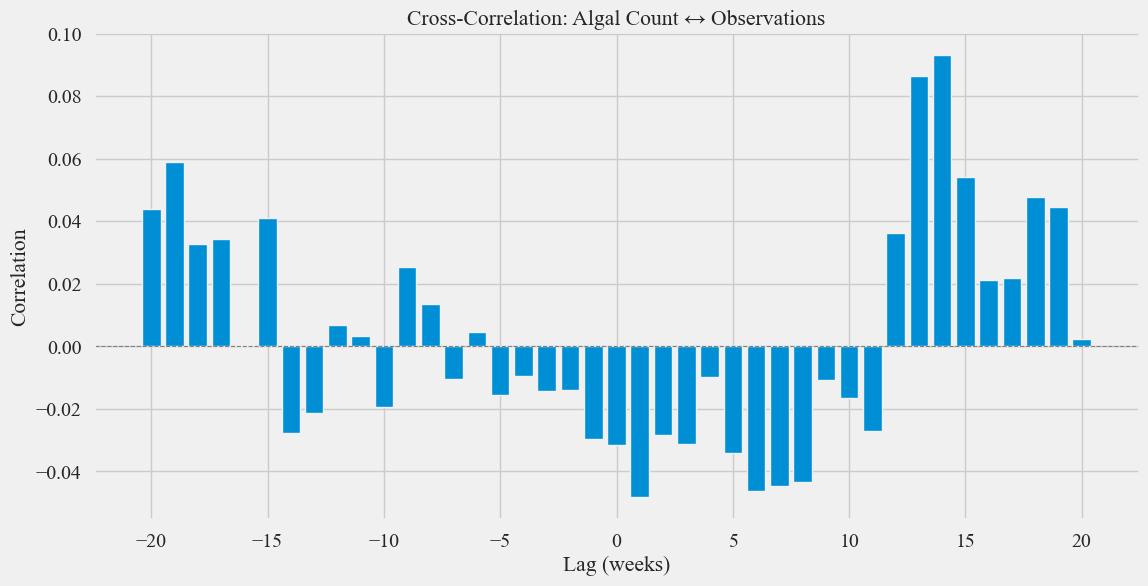

Lag (weeks) | Correlation Coefficient
-20          | 0.0440
-19          | 0.0590
-18          | 0.0327
-17          | 0.0344
-16          | 0.0006
-15          | 0.0410
-14          | -0.0279
-13          | -0.0214
-12          | 0.0068
-11          | 0.0034
-10          | -0.0194
-9           | 0.0252
-8           | 0.0134
-7           | -0.0103
-6           | 0.0045
-5           | -0.0156
-4           | -0.0096
-3           | -0.0141
-2           | -0.0140
-1           | -0.0297
0            | -0.0315
1            | -0.0482
2            | -0.0282
3            | -0.0312
4            | -0.0098
5            | -0.0341
6            | -0.0463
7            | -0.0448
8            | -0.0435
9            | -0.0107
10           | -0.0165
11           | -0.0270
12           | 0.0361
13           | 0.0865
14           | 0.0931
15           | 0.0540
16           | 0.0213
17           | 0.0220
18           | 0.0479
19           | 0.0447
20           | 0.0022

Interpretations:
At lag -20, a weak or

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
import numpy as np

# Load your dataset
path = 'C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/gulf_week_sst.csv'
sst = pd.read_csv(path)

# Rename for ease
sst = sst.rename(columns={'avg_algal_COUNT_': 'algal_count', 'observations': 'obs'})

# Drop rows with missing values in the two relevant columns
sst_clean = sst[['by_week', 'obs', 'algal_count']].dropna()

# Optional: sort by date if needed
sst_clean['by_week'] = pd.to_datetime(sst_clean['by_week'])
sst_clean = sst_clean.sort_values('by_week')

# Extract the time series
obs_series = sst_clean['obs'].values
algal_series = sst_clean['algal_count'].values

# Normalize (optional but recommended)
obs_series = (obs_series - obs_series.mean()) / obs_series.std()
algal_series = (algal_series - algal_series.mean()) / algal_series.std()

# Define max lag
max_lag = 20

# Compute full cross-correlation
full_ccf = np.correlate(algal_series - algal_series.mean(), obs_series - obs_series.mean(), mode='full')
full_ccf = full_ccf / (len(algal_series) * algal_series.std() * obs_series.std())

# Extract lags
lags = np.arange(-max_lag, max_lag + 1)
center = len(full_ccf) // 2
ccf_values = full_ccf[center - max_lag:center + max_lag + 1]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(lags, ccf_values)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Cross-Correlation: Algal Count ↔ Observations')
plt.xlabel('Lag (weeks)')
plt.ylabel('Correlation')
plt.grid(True)
plt.show()

# Print lag and correlation values
print("Lag (weeks) | Correlation Coefficient")
for lag, r in zip(lags, ccf_values):
    print(f"{lag:<12} | {r:.4f}")

# Interpret each correlation coefficient
print("\nInterpretations:")
for lag, r in zip(lags, ccf_values):
    if r > 0.3:
        interpretation = f"At lag {lag}, a strong positive correlation ({r:.2f}) suggests that algal blooms may be a leading indicator of increased strandings or alerts {abs(lag)} weeks {'later' if lag > 0 else 'earlier'}."
    elif r > 0.1:
        interpretation = f"At lag {lag}, a moderate positive correlation ({r:.2f}) indicates a possible association between algal abundance and ecological disruptions {abs(lag)} weeks {'later' if lag > 0 else 'earlier'}."
    elif r < -0.1:
        interpretation = f"At lag {lag}, a negative correlation ({r:.2f}) may imply that algal blooms are inversely related to strandings or alerts {abs(lag)} weeks {'later' if lag > 0 else 'earlier'}."
    else:
        interpretation = f"At lag {lag}, a weak or negligible correlation ({r:.2f}) suggests limited direct association at this lag."
    print(interpretation)


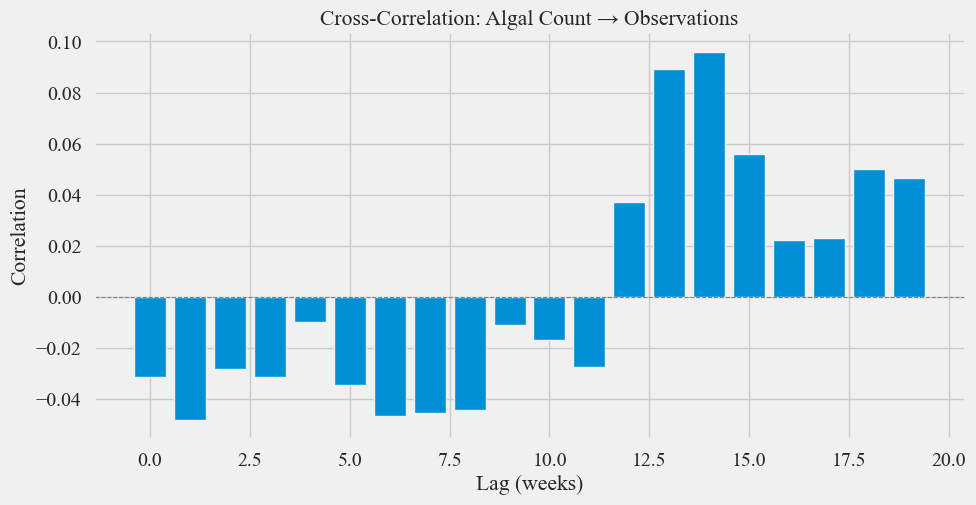

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# Load your dataset
path  = 'C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/gulf_week_sst.csv'
sst = pd.read_csv(path)

# Rename for ease
sst = sst.rename(columns={'avg_algal_COUNT_': 'algal_count', 'observations': 'obs'})

# Drop rows with missing values in the two relevant columns
sst_clean = sst[['by_week', 'obs', 'algal_count']].dropna()

# Optional: sort by date if needed
sst_clean['by_week'] = pd.to_datetime(sst_clean['by_week'])
sst_clean = sst_clean.sort_values('by_week')

# Extract the time series
obs_series = sst_clean['obs'].values
algal_series = sst_clean['algal_count'].values

# Normalize (optional but recommended)
obs_series = (obs_series - obs_series.mean()) / obs_series.std()
algal_series = (algal_series - algal_series.mean()) / algal_series.std()

# Plot cross-correlation using statsmodels
lags = 20  # check +/- 20 weeks lag
ccf_values = ccf(algal_series, obs_series)[:lags]

plt.figure(figsize=(10, 5))
plt.bar(range(lags), ccf_values)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Cross-Correlation: Algal Count → Observations')
plt.xlabel('Lag (weeks)')
plt.ylabel('Correlation')
plt.show()

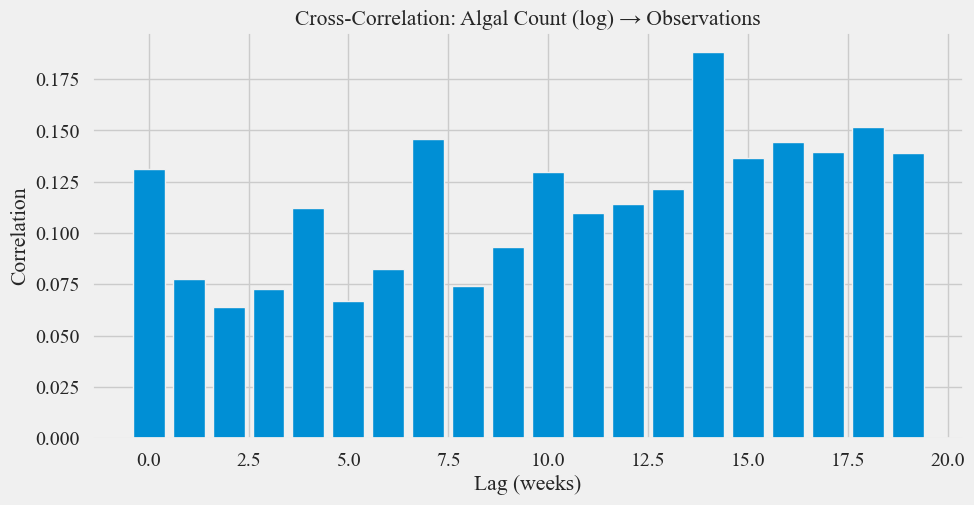

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# Load your dataset
path  = 'C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/gulf_week_sst.csv'
sst = pd.read_csv(path)

# Rename for ease
sst = sst.rename(columns={'log_algal_count': 'log_algal_count', 'observations': 'obs'})

# Drop rows with missing values in the two relevant columns
sst_clean = sst[['by_week', 'obs', 'log_algal_count']].dropna()

# Optional: sort by date if needed
sst_clean['by_week'] = pd.to_datetime(sst_clean['by_week'])
sst_clean = sst_clean.sort_values('by_week')

# Extract the time series
obs_series = sst_clean['obs'].values
algal_series = sst_clean['log_algal_count'].values

# Normalize (optional but recommended)
obs_series = (obs_series - obs_series.mean()) / obs_series.std()
algal_series = (algal_series - algal_series.mean()) / algal_series.std()

# Plot cross-correlation using statsmodels
lags = 20  # check +/- 20 weeks lag
ccf_values = ccf(algal_series, obs_series)[:lags]

plt.figure(figsize=(10, 5))
plt.bar(range(lags), ccf_values)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Cross-Correlation: Algal Count (log) → Observations')
plt.xlabel('Lag (weeks)')
plt.ylabel('Correlation')
plt.show()

In [15]:
sst

,Unnamed: 0,by_week,obs,avg_algal_COUNT_,bird_latitude,bird_longitude,log_algal_count,cube_algal,nearest_latitude,nearest_longitude,sst
0,1,2015-12-27,1,0.000000,-27.352000,-82.411000,0.000000,0.000000,NaN,NaN,NaN
1,2,2016-01-03,734,0.000000,-27.352000,-82.411000,0.000000,0.000000,24.771044,-80.197097,289.48
2,3,2016-01-10,626,0.000000,-27.352000,-82.411000,0.000000,0.000000,NaN,NaN,NaN
3,4,2016-01-17,122,0.000000,-27.352000,-82.411000,0.000000,0.000000,NaN,NaN,NaN
4,5,2016-01-24,21,376045.363636,26.515996,-81.945220,12.837468,72.179424,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
449,450,2024-08-04,196,0.000000,-27.352000,-82.411000,0.000000,0.000000,24.771044,-82.038643,313.57
450,451,2024-08-11,841,0.000000,-27.352000,-82.411000,0.000000,0.000000,NaN,NaN,NaN
451,452,2024-08-18,4,0.000000,-27.352000,-82.411000,0.000000,0.000000,24.771044,-82.622548,311.41
452,453,2024-08-25,150,0.000000,-27.352000,-82.411000,0.000000,0.000000,24.771044,-82.397969,325.33


In [15]:
# Drop rows with missing values in the two relevant columns

sst_clean = sst[['by_week', 'obs', 'algal_count']].dropna()

# Optional: sort by date if needed
sst_clean['by_week'] = pd.to_datetime(sst_clean['by_week'])
sst_clean = sst_clean.sort_values('by_week')

# Extract the time series
obs_series = sst_clean['obs'].values
algal_series = sst_clean['algal_count'].values

# Normalize (optional but recommended)
obs_series = (obs_series - obs_series.mean()) / obs_series.std()
algal_series = (algal_series - algal_series.mean()) / algal_series.std()

# Plot cross-correlation using statsmodels
lags = 20  # check +/- 20 weeks lag
ccf_values = ccf(algal_series, obs_series)[:lags]

plt.figure(figsize=(10, 5))
plt.bar(range(lags), ccf_values)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Cross-Correlation: Algal Count → Observations')
plt.xlabel('Lag (weeks)')
plt.ylabel('Correlation')
plt.show()

KeyError: "['algal_count'] not in index"

In [16]:
import numpy as np
from statsmodels.tsa.stattools import ccf

# Define symmetric lags
max_lag = 10

# Make both series same length and drop NA
sst_clean = sst[['by_week', 'obs', 'algal_count']].dropna()
sst_clean['by_week'] = pd.to_datetime(sst_clean['by_week'])
sst_clean = sst_clean.sort_values('by_week')

obs_series = sst_clean['obs'].values
algal_series = sst_clean['algal_count'].values

# Standardize
obs_series = (obs_series - obs_series.mean()) / obs_series.std()
algal_series = (algal_series - algal_series.mean()) / algal_series.std()

# Compute full cross-correlation
full_ccf = np.correlate(algal_series - algal_series.mean(), obs_series - obs_series.mean(), mode='full')
full_ccf = full_ccf / (len(obs_series) * obs_series.std() * algal_series.std())

# Center lags around 0
lags = np.arange(-len(obs_series)+1, len(obs_series))
mid = len(full_ccf) // 2
selected_lags = np.arange(-max_lag, max_lag + 1)
selected_ccf = full_ccf[mid - max_lag: mid + max_lag + 1]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(selected_lags, selected_ccf, width=0.8)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Cross-Correlation: Algal Count ↔ Observations')
plt.xlabel('Lag (weeks)')
plt.ylabel('Correlation')
plt.xticks(selected_lags)  # ensures integer week labels
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/CCF_Algal_bloom_strandings.png', dpi = 600)
plt.show()

KeyError: "['algal_count'] not in index"

In [17]:
import numpy as np
from statsmodels.tsa.stattools import ccf

# Define symmetric lags
max_lag = 10

# Make both series same length and drop NA
sst_clean = sst[['by_week', 'obs', 'algal_count']].dropna()
sst_clean['by_week'] = pd.to_datetime(sst_clean['by_week'])
sst_clean = sst_clean.sort_values('by_week')

obs_series = sst_clean['obs'].values
algal_series = sst_clean['algal_count'].values

# Standardize
obs_series = (obs_series - obs_series.mean()) / obs_series.std()
algal_series = (algal_series - algal_series.mean()) / algal_series.std()

# Compute full cross-correlation
full_ccf = np.correlate(obs_series - obs_series.mean(), algal_series - algal_series.mean(), mode='full')
full_ccf = full_ccf / (len(obs_series) * obs_series.std() * algal_series.std())

# Center lags around 0
lags = np.arange(-len(obs_series)+1, len(obs_series))
mid = len(full_ccf) // 2
selected_lags = np.arange(-max_lag, max_lag + 1)
selected_ccf = full_ccf[mid - max_lag: mid + max_lag + 1]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(selected_lags, selected_ccf, width=0.8)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Cross-Correlation: Algal Count ↔ Observations')
plt.xlabel('Lag (weeks)')
plt.ylabel('Correlation')
plt.xticks(selected_lags)  # ensures integer week labels
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/CCF_Algal_bloom_strandings.png', dpi = 600)
plt.show()

KeyError: "['algal_count'] not in index"

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define symmetric lags
max_lag = 10

# Make both series same length and drop NA
sst_clean = sst[['by_week', 'obs', 'algal_count']].dropna()
sst_clean['by_week'] = pd.to_datetime(sst_clean['by_week'])
sst_clean = sst_clean.sort_values('by_week')

obs_series = sst_clean['obs'].values
algal_series = sst_clean['algal_count'].values
# Standardize
obs_series = (obs_series - obs_series.mean()) / obs_series.std()
algal_series = (algal_series - algal_series.mean()) / algal_series.std()

# Compute full cross-correlation
full_ccf = np.correlate(obs_series - obs_series.mean(), algal_series - algal_series.mean(), mode='full')
full_ccf = full_ccf / (len(obs_series) * obs_series.std() * algal_series.std())

# Center lags around 0
lags = np.arange(-len(obs_series)+1, len(obs_series))
mid = len(full_ccf) // 2
selected_lags = np.arange(-max_lag, max_lag + 1)
selected_ccf = full_ccf[mid - max_lag: mid + max_lag + 1]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(selected_lags, selected_ccf, width=0.8)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Cross-Correlation: Algal Count ↔ Observations')
plt.xlabel('Lag (weeks)')
plt.ylabel('Correlation')
plt.xticks(selected_lags)
plt.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/CCF_Algal_bloom_strandings.png', dpi=600)
plt.show()

# Create and print table with interpretations
def interpret(lag, r):
    if r > 0.3:
        return f"Strong positive correlation: algal blooms may precede strandings by {lag} weeks" if lag > 0 else f"Strong positive correlation: strandings may precede algal blooms by {-lag} weeks"
    elif r > 0.1:
        return f"Moderate positive correlation: possible link {lag} weeks {'later' if lag > 0 else 'earlier'}"
    elif r < -0.1:
        return f"Negative correlation: inverse relationship {abs(lag)} weeks {'later' if lag > 0 else 'earlier'}"
    else:
        return "Weak or negligible correlation"

# Build DataFrame
df = pd.DataFrame({
    'Lag (weeks)': selected_lags,
    'Correlation Coefficient (r)': selected_ccf,
    'Interpretation': [interpret(lag, r) for lag, r in zip(selected_lags, selected_ccf)]
})

# Print nicely
print("\nCross-Correlation Table:\n")
print(df.to_string(index=False))


KeyError: "['algal_count'] not in index"

## Avian Mortality data

In [1]:
path  = 'C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/AV_Exports/avianmortality-report.csv'

In [2]:
# Load the CSV file with automatic delimiter detection and skip malformed lines
df = pd.read_csv(path, sep=None, engine='python', on_bad_lines='skip')
# Display the first few rows
df.head()

NameError: name 'pd' is not defined

In [54]:

# Try with different separators
df_comma = pd.read_csv(path, sep=",", engine='python')
df_tab = pd.read_csv(path, sep="\t", engine='python')
df_pipe = pd.read_csv(path, sep="|", engine='python')
df_semicolon = pd.read_csv(path, sep=";", engine='python')

ParserError: Expected 1 fields in line 69, saw 3

In [55]:
df_pipe.head()

,ID TimeReported Name Phone Email Affiliation County LAT LON Trauma Condition Comments EmployeeEdit CarcassAvailable City Collector EditDead EditSick RptDead RptSick RptDeadSick ReportedTotal EditDate DateObserved DateReported
0,49 13:38:59.7462865 Leon Cao ...
1,50 15:35:07.1680749 Veronica Vargas ...
2,51 16:17:02.2404855 TEST ...
3,52 16:33:57.9046042 Carly Dolinski ...
4,53 16:35:54.8712615 Carly Dolinski ...


In [41]:
df_comma.head()

,ID TimeReported Name Phone Email Affiliation County LAT LON Trauma Condition Comments EmployeeEdit CarcassAvailable City Collector EditDead EditSick RptDead RptSick RptDeadSick ReportedTotal EditDate DateObserved DateReported,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,49 13:38:59.7462865 Leon Cao ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50 15:35:07.1680749 Veronica Vargas ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,51 16:17:02.2404855 TEST ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,52 16:33:57.9046042 Carly Dolinski ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,53 16:35:54.8712615 Carly Dolinski ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_space = pd.read_csv(path, delim_whitespace=True)
df_space.head()

ParserError: Error tokenizing data. C error: Expected 32 fields in line 3, saw 53


In [43]:
cleaned_lines = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()  # splits on any whitespace
        cleaned_lines.append(",".join(parts))

# Save cleaned file
with open("cleaned_file.csv", "w", encoding="utf-8") as f:
    f.write("\n".join(cleaned_lines))

In [47]:
with open(path, "r", encoding="utf-8") as f:
    for i in range(2):
        print(f.readline())

﻿ID          TimeReported     Name                                                                                                                                                                                                                                                            Phone                                              Email                                              Affiliation                                        County                                             LAT                    LON                    Trauma                                             Condition                                          Comments                                                                                                                                                                                                                                                         EmployeeEdit                                       CarcassAvailable                                   Cit

In [49]:
import pandas as pd

df = pd.read_csv(path, sep=",", quotechar='"', encoding='utf-8', engine='python')  # more forgiving parser
df.head()


,ID TimeReported Name Phone Email Affiliation County LAT LON Trauma Condition Comments EmployeeEdit CarcassAvailable City Collector EditDead EditSick RptDead RptSick RptDeadSick ReportedTotal EditDate DateObserved DateReported
0,49 13:38:59.7462865 Leon Cao ...
1,50 15:35:07.1680749 Veronica Vargas ...
2,51 16:17:02.2404855 TEST ...
3,52 16:33:57.9046042 Carly Dolinski ...
4,53 16:35:54.8712615 Carly Dolinski ...


In [50]:
df = pd.read_csv(path, delim_whitespace=True)
df.head()

ParserError: Error tokenizing data. C error: Expected 32 fields in line 3, saw 53
